В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import pyarrow.parquet as pq
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, f1_score
import joblib

Matplotlib is building the font cache; this may take a moment.


In [2]:
df = pd.read_csv('/Users/shein/CourseML/data/bank-customer-churn-prediction-dlu-course-c-5/train.csv')

In [3]:
y = df.Exited

In [4]:
train_df, val_df = train_test_split(df, test_size=0.25, stratify=y, random_state=42)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               15000 non-null  int64  
 1   CustomerId       15000 non-null  float64
 2   Surname          15000 non-null  object 
 3   CreditScore      15000 non-null  float64
 4   Geography        15000 non-null  object 
 5   Gender           15000 non-null  object 
 6   Age              15000 non-null  float64
 7   Tenure           15000 non-null  float64
 8   Balance          15000 non-null  float64
 9   NumOfProducts    15000 non-null  float64
 10  HasCrCard        15000 non-null  float64
 11  IsActiveMember   15000 non-null  float64
 12  EstimatedSalary  15000 non-null  float64
 13  Exited           15000 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.6+ MB


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

In [10]:
input_cols = list(train_df.columns)[3:-1]
target_col = 'Exited'

In [11]:
input_cols

['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary']

In [12]:
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [13]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

In [16]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11250 entries, 8263 to 1292
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               11250 non-null  int64  
 1   CustomerId       11250 non-null  float64
 2   Surname          11250 non-null  object 
 3   CreditScore      11250 non-null  float64
 4   Geography        11250 non-null  object 
 5   Gender           11250 non-null  object 
 6   Age              11250 non-null  float64
 7   Tenure           11250 non-null  float64
 8   Balance          11250 non-null  float64
 9   NumOfProducts    11250 non-null  float64
 10  HasCrCard        11250 non-null  float64
 11  IsActiveMember   11250 non-null  float64
 12  EstimatedSalary  11250 non-null  float64
 13  Exited           11250 non-null  float64
dtypes: float64(10), int64(1), object(3)
memory usage: 1.3+ MB


In [25]:
train_inputs.head(5)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
8263,696.0,France,Male,32.0,5.0,130627.66,1.0,1.0,1.0,86786.41
14199,632.0,Germany,Female,32.0,4.0,119825.75,1.0,1.0,0.0,177737.04
1856,679.0,France,Female,22.0,4.0,0.00,2.0,1.0,1.0,162599.54
3013,705.0,France,Male,48.0,3.0,0.00,2.0,1.0,0.0,119814.25
8266,696.0,France,Female,35.0,7.0,0.00,2.0,1.0,0.0,100423.88


In [26]:
train_inputs[categorical_cols].nunique()

Geography    3
Gender       2
dtype: int64

In [32]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [33]:
encoder.fit(train_inputs[['Geography']])

OneHotEncoder(handle_unknown='ignore', sparse_output=False)

In [34]:
encoded_cols = list(encoder.get_feature_names_out(['Geography']))
encoded_cols

['Geography_France', 'Geography_Germany', 'Geography_Spain']

In [35]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[['Geography']])
val_inputs[encoded_cols] = encoder.transform(val_inputs[['Geography']])

In [38]:
gender_code = {'Female': 0, 'Male': 1}
train_inputs['gender_code'] = train_inputs.Gender.map(gender_code)
val_inputs['gender_code'] = val_inputs.Gender.map(gender_code)

In [39]:
#train_inputs.drop(['CustomerId', 'Surname', 'Geography', 'Gender'], axis=1, inplace=True)
#val_inputs.drop(['CustomerId', 'Surname', 'Geography', 'Gender'], axis=1, inplace=True)

train_inputs.drop(['Geography', 'Gender'], axis=1, inplace=True)
val_inputs.drop(['Geography', 'Gender'], axis=1, inplace=True)

In [44]:
scaler = MinMaxScaler()

In [59]:
scaler.fit(train_inputs[numeric_cols + ['gender_code']])

MinMaxScaler()

In [60]:
train_inputs[numeric_cols + ['gender_code']] = scaler.transform(train_inputs[numeric_cols + ['gender_code']])
val_inputs[numeric_cols + ['gender_code']] = scaler.transform(val_inputs[numeric_cols + ['gender_code']])

In [61]:
display(train_inputs.round(2)[:5], val_inputs.round(2)[:5])

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,gender_code
8263,0.63,0.26,0.5,0.62,0.00,1.0,1.0,0.43,1.0,0.0,0.0,1.0
14199,0.48,0.26,0.4,0.57,0.00,1.0,0.0,0.89,0.0,1.0,0.0,0.0
1856,0.59,0.07,0.4,0.00,0.33,1.0,1.0,0.81,1.0,0.0,0.0,0.0
3013,0.65,0.56,0.3,0.00,0.33,1.0,0.0,0.60,1.0,0.0,0.0,1.0
8266,0.63,0.31,0.7,0.00,0.33,1.0,0.0,0.50,1.0,0.0,0.0,0.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,gender_code
1855,0.27,0.20,0.9,0.57,0.0,0.0,0.0,0.28,1.0,0.0,0.0,1.0
1273,0.40,0.43,0.3,0.59,0.0,1.0,0.0,0.88,0.0,1.0,0.0,1.0
5414,0.45,0.24,0.7,0.00,0.0,1.0,1.0,0.75,1.0,0.0,0.0,1.0
10923,0.40,0.70,0.3,0.00,1.0,1.0,0.0,0.51,1.0,0.0,0.0,1.0
5835,0.76,0.44,0.5,0.00,0.0,1.0,1.0,0.91,0.0,0.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [63]:
train_inputs.to_parquet('train_inputs.parquet')
val_inputs.to_parquet('val_inputs.parquet')

In [64]:
pd.DataFrame(train_targets).to_parquet('train_targets.parquet')
pd.DataFrame(val_targets).to_parquet('val_targets.parquet')

In [65]:
!ls

HW1_Змінні_та_основні_типи_даних_в_Python_ipynb_.ipynb
HW2_Списки_та_словники_ipynb_.ipynb
HW3_Умовні_конструкції_(if_elif_else)_ipynb_.ipynb
HW4_Цикл_for_ipynb_.ipynb
HW5_Цикл_while_List_comprehensions_ipynb_.ipynb
HW6_Функції_ipynb_.ipynb
HW7_Numpy_ipynb_.ipynb
HW8_Pandas_ipynb_.ipynb
HW9_Data_Visualization_ipynb_.ipynb
HW_1_2_Credit_EDA.ipynb
HW_2_1_Building_a_linear_regression_on_a_single_variable.ipynb
HW_2_1_Feature_Analysis_for_Constructing_Linear_Regression.ipynb
HW_2_1_Linear_regression_on_multiple_variables.ipynb
HW_2_1_Matrices_and_vectors_(Introduction_to_linear_algebra).ipynb
HW_2_1_functions_and_derivatives.ipynb
HW_2_1_statistical_hypothesis_testing.ipynb
HW_2_2_Logistic_regression_with_scikit_learn.ipynb
HW_2_2_Mathematical Formulation of Logistic Regression.ipynb
ML_course_HW_1.ipynb
train_inputs.parquet
train_targets.parquet
val_inputs.parquet
val_targets.parquet


6. З підготовлених вхіжних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [66]:
X_train = train_inputs
X_val = val_inputs

In [67]:
model = LogisticRegression(solver='liblinear')

In [68]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

In [70]:
X_train.head().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,gender_code
8263,0.63,0.26,0.5,0.62,0.00,1.0,1.0,0.43,1.0,0.0,0.0,1.0
14199,0.48,0.26,0.4,0.57,0.00,1.0,0.0,0.89,0.0,1.0,0.0,0.0
1856,0.59,0.07,0.4,0.00,0.33,1.0,1.0,0.81,1.0,0.0,0.0,0.0
3013,0.65,0.56,0.3,0.00,0.33,1.0,0.0,0.60,1.0,0.0,0.0,1.0
8266,0.63,0.31,0.7,0.00,0.33,1.0,0.0,0.50,1.0,0.0,0.0,0.0


In [75]:
train_preds = model.predict(X_train)

In [76]:
confusion_matrix(train_targets, train_preds)

array([[8601,  360],
       [1048, 1241]])

In [78]:
def predict_and_plot(inputs, targets, title = ''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print('Accuracy: {:.2f}%'.format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(title));

Accuracy: 87.48%


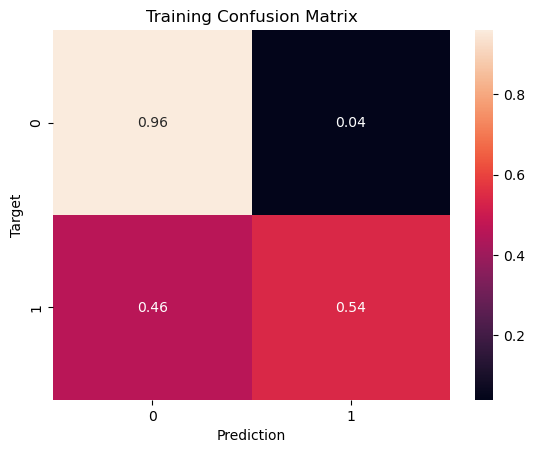

In [79]:
train_preds = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 87.09%


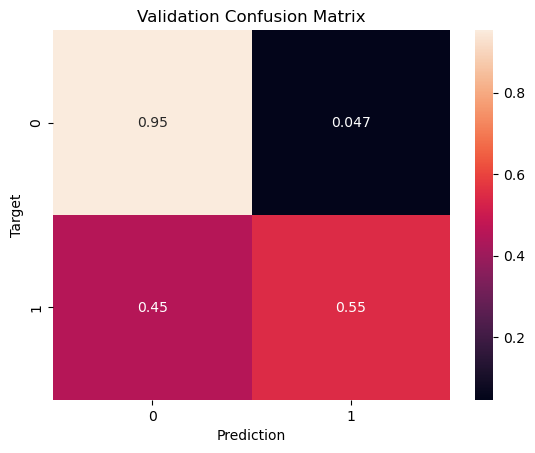

In [80]:
val_preds = predict_and_plot(X_val, val_targets, 'Validation')

In [83]:
def compute_auroc_and_build_roc(inputs, targets, name = ''):

    y_pred_proba = model.predict_proba(inputs)[:, 1]

    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    roc_auc = auc(fpr, tpr)
    print(f'Area Under the ROC Curve (AUROC) for {name}: {roc_auc:.2f}')

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
    plt.legend(loc="lower right")
    plt.show();

Area Under the ROC Curve (AUROC) for Training: 0.88


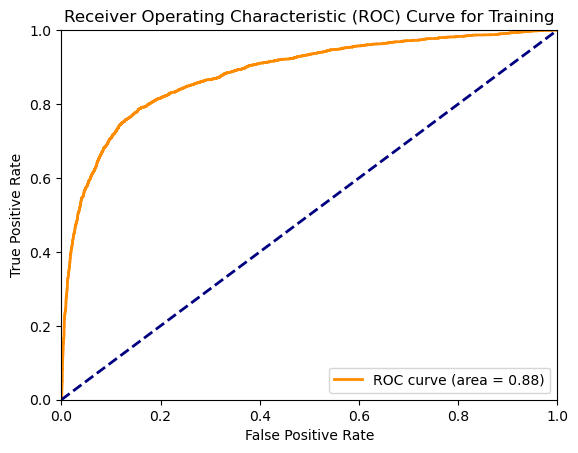

Area Under the ROC Curve (AUROC) for Validation: 0.88


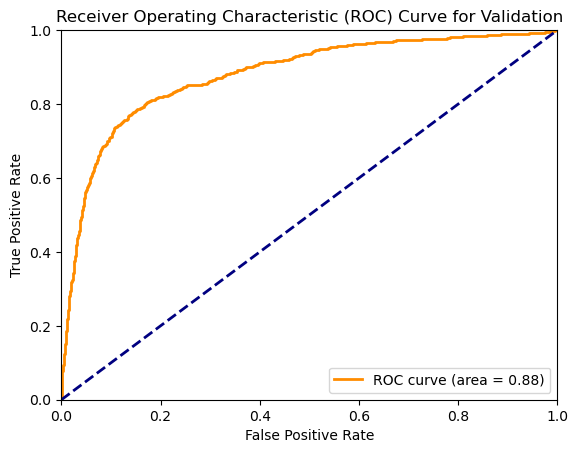

In [84]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

In [85]:
def get_f1_score(inputs, targets, name = ''):
    preds = model.predict(inputs)

    f1_score_ = f1_score(targets, preds)
    print(f'F1 Score: {name}: {f1_score_:.2f}%')
          

In [86]:
get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 Score: Training: 0.64%
F1 Score: Validation: 0.63%


Якість моделі доволі хороша. Ми отримали точність на рівні 87,48% і 87,09% на тренувальному і валідаційному наборі даних відповідно, що свідчить про те, що модель гарно передбачає на даних, які ще не бачила. AUC 0,88 - це дуже хороший результат, він свідчить про те, що модель добре узагальнює дані, а дані в обох наборах розподілені з одинаковим рівнем складності. F1 score також свідчить про те, що модель якісна.

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

In [87]:
train_targets.value_counts()

Exited
0.0    8961
1.0    2289
Name: count, dtype: int64

In [104]:
val_targets.value_counts()

Exited
0.0    2987
1.0     763
Name: count, dtype: int64

In [94]:
def all_zeros(inputs):
    return np.full(len(inputs), 0)

In [99]:
accuracy_score(train_targets, all_zeros(X_train))

0.7965333333333333

In [96]:
accuracy_score(val_targets, all_zeros(X_val))

0.7965333333333333

Модель хороша. Точність моделі на рівні 87%. Незважаючи на те, що результат точності для вхідних даних, що позначають тільки мажоритарний клас, досить високий, це не означає, що наша модель погана, адже співвідношення класів в наборах даних дуже зміщено в сторону мажоритарного.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [111]:
model_1 = {
    'model': model, 
    'encoder': encoder, 
    'scaler': scaler, 
    'input_cols': input_cols, 
    'target_col': target_col, 
    'numeric_cols': numeric_cols, 
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
    }
joblib.dump(model_1, 'log_reg.joblib')

['log_reg.joblib']

In [112]:
model_2 = joblib.load('log_reg.joblib')

In [113]:
model_2

{'model': LogisticRegression(solver='liblinear'),
 'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
 'scaler': MinMaxScaler(),
 'input_cols': ['CreditScore',
  'Geography',
  'Gender',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 'target_col': 'Exited',
 'numeric_cols': ['CreditScore',
  'Age',
  'Tenure',
  'Balance',
  'NumOfProducts',
  'HasCrCard',
  'IsActiveMember',
  'EstimatedSalary'],
 'categorical_cols': ['Geography', 'Gender'],
 'encoded_cols': ['Geography_France', 'Geography_Germany', 'Geography_Spain']}

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

def predict_raw_df(scaler, encoder, numeric_cols, encoded_cols, input_df: pd.DataFrame):
    encoded_cols = list(encoder.get_feature_names_out(['Geography']))
    input_df[encoded_cols] = encoder.transform(input_df[['Geography']])
    gender_code = {'Female': 0, 'Male': 1}
    input_df['gender_code'] = input_df.Gender.map(gender_code)
    input_df[numeric_cols + ['gender_code']] = scaler.transform(input_df[numeric_cols + ['gender_code']])
    input_df = input_df.drop(['Geography', 'Gender'], axis=1)
    X_input = input_df[numeric_cols + encoded_cols + ['gender_code']]

    prob = model.predict_proba(X_input)[:,1]
    return prob

In [115]:
print(X_train.columns.tolist())

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'gender_code']


In [123]:
predict_raw_df(scaler, encoder, numeric_cols, encoded_cols, df[:5])

array([1., 1., 1., 0., 0.])

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [124]:
test_raw_df = pd.read_csv('/Users/shein/CourseML/data/bank-customer-churn-prediction-dlu-course-c-5/test.csv')

In [125]:
predict_raw_df(scaler, encoder, numeric_cols, encoded_cols, test_raw_df)

array([0., 1., 1., ..., 1., 0., 1.])

In [126]:
test_raw_df['Exited'] = predict_raw_df(scaler, encoder, numeric_cols, encoded_cols, test_raw_df)

12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [127]:
submission_df = pd.read_csv('/Users/shein/CourseML/data/bank-customer-churn-prediction-dlu-course-c-5/sample_submission.csv')

In [128]:
submission_df['Exited'] = test_raw_df['Exited'] 

In [131]:
submission_df.to_csv("submission_log_reg.csv", index=False)